In [2]:
import numpy as np
import matplotlib.pyplot as plt
from resampling import resampling
import matplotlib as mplt

In [3]:
def getFigurePaper(size=40, labelsize=20, linewidth=6, markersize=10):
    size = size
    mplt.rcParams["lines.linewidth"] = linewidth
    mplt.rcParams["font.size"] = size
    mplt.rcParams["font.family"] = "serif"
    mplt.rcParams["font.serif"] = "Computer Modern Roman"
    mplt.rcParams["font.weight"] = "heavy"
    mplt.rcParams["legend.fontsize"] = size
    mplt.rcParams["axes.labelsize"] = size
    mplt.rcParams["axes.titlesize"] = size
    mplt.rcParams["text.usetex"] = True
    mplt.rcParams["axes.linewidth"] = 2.5
    mplt.rcParams["lines.markersize"] = markersize
    mplt.rcParams["lines.markeredgewidth"] = 1
    mplt.rcParams["xtick.major.size"] = 10
    mplt.rcParams["xtick.minor.size"] = 0
    mplt.rcParams["ytick.major.size"] = 10
    mplt.rcParams["ytick.minor.size"] = 0
    mplt.rcParams["xtick.labelsize"] = labelsize
    mplt.rcParams["ytick.labelsize"] = labelsize
    mplt.rcParams["xtick.direction"] = "in"
    mplt.rcParams["ytick.direction"] = "in"
    mplt.rcParams[
        "text.latex.preamble"
    ] = r"\newcommand{\sub}[1]{\textrm{\fontsize{10}{10}\selectfont #1}} \usepackage{amsmath} \usepackage{amsfonts} \usepackage{amssymb}"
    mplt.rcParams['axes.linewidth'] = 1.5
    fig = plt.figure(figsize=(1.5 * 5.0, 3))
    plt.rcParams["figure.dpi"] = 300
    plt.rcParams["savefig.dpi"] = 300

    return fig

In [4]:
Ms = np.array([2, 4, 6, 8, 10, 12, 14, 16])
means = []
errs = []

for M in Ms: 
    times = np.loadtxt(f"times_K={M}_largermodel.txt")[10:]
    means.append(np.mean(times))
    errs.append(np.std(times)/np.sqrt(len(times)))
means = np.array(means)
errs = np.array(errs)

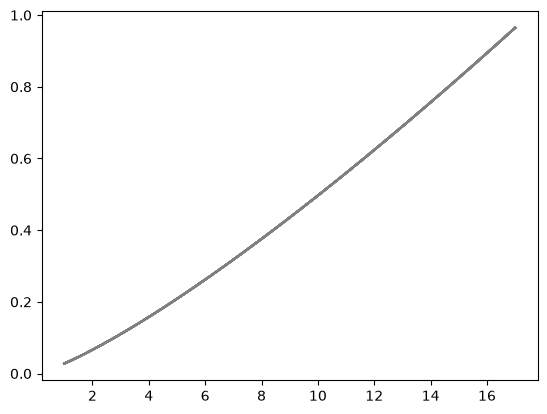

In [5]:
num_resamples = 1000
# model_func = lambda M, a, b, c: a + b * M + c * M**2
model_func = lambda M, a, b: b * M**a
seed = 42
Ms_fit = np.linspace(Ms.min()-1, Ms.max()+1, 1000)
params_mean, params_std = resampling(means, errs, num_resamples, Ms, Ms_fit, model_func, seed, plot=True)

/var/folders/79/jcbbyf357tn_ctl5c6wsbn1h0000gp/T/ipykernel_42314/755166899.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 2250x900 with 0 Axes>

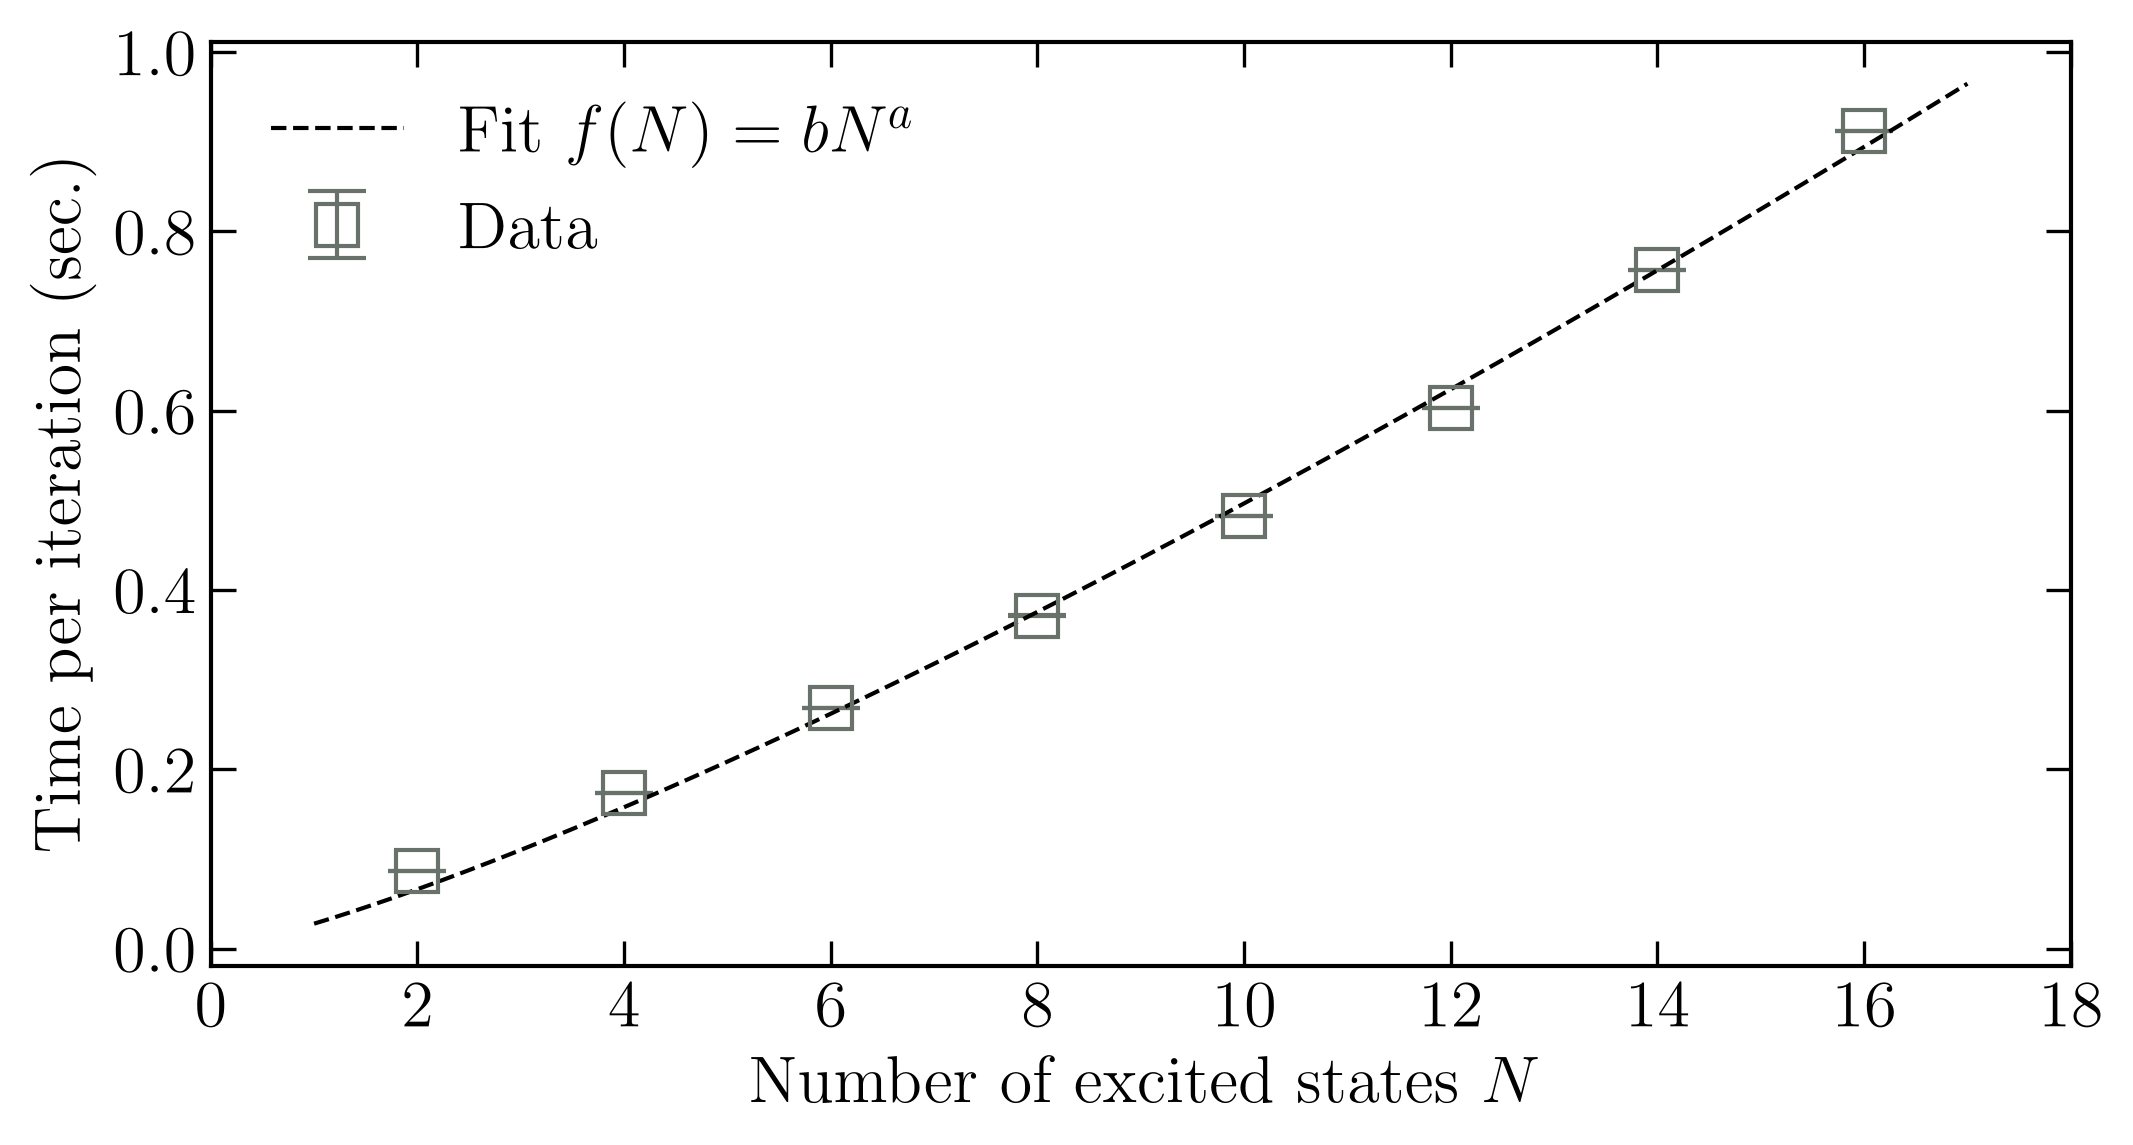

In [9]:
colors = ["#B9D14C", "#69BC78", "#68726A", "#414483", "#2C728E", "#440154"]
color = colors[2]

size = 16
linewidth = 1
markersize = 10
ecolor = color
capsize = 7
capthick = 1
elinewidth = 1

getFigurePaper(size=size, linewidth=1, labelsize=size, markersize=markersize)

fig, ax = plt.subplots()
fig.set_size_inches(8, 4)
ax.errorbar(Ms, means, yerr=errs, fmt='s', markeredgecolor=color, markerfacecolor="none", ecolor=ecolor, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='Data')
ax.plot(Ms_fit, model_func(Ms_fit, *params_mean), label='Fit $f(N) = b N^{a}$', linestyle='--', color='black')
ax.set_xlabel('Number of excited states $N$')
ax.set_ylabel('Time per iteration (sec.)')

ax.spines["top"].set_linewidth(1.0)
ax.spines["right"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.spines["left"].set_linewidth(1.0)

ax.legend(fontsize=16, frameon=False)

ax.set_xticks(np.arange(0, 20, 2))

ax.tick_params(
    axis="both", which="major", length=6, direction="in", top=True, right=True
)

fig.show()
fig.savefig("cost.pdf", bbox_inches='tight')

In [11]:
print(params_mean)
print(params_std)

[1.25164964 0.02782034]
[3.73885799e-04 2.52920833e-05]
